Dữ liệu ban đầu:
  area  hour  population  income  demand
0    A     7       10000      12     120
1    A    12       10000      12     180
2    A    18       10000      12     240
3    B     7       18000      18     220
4    B    12       18000      18     320
5    B    18       18000      18     410
6    C     7        9000      10      90
7    C    12        9000      10     130
8    C    18        9000      10     170

Kết quả dự đoán:
  area  hour  demand  predicted_demand
0    A     7     120        117.191697
1    A    12     180        176.074481
2    A    18     240        246.733822
3    B     7     220        253.858364
4    B    12     320        312.741148
5    B    18     410        383.400488
6    C     7      90         67.191697
7    C    12     130        126.074481
8    C    18     170        196.733822

Sai số MAE = 14.961334961334972


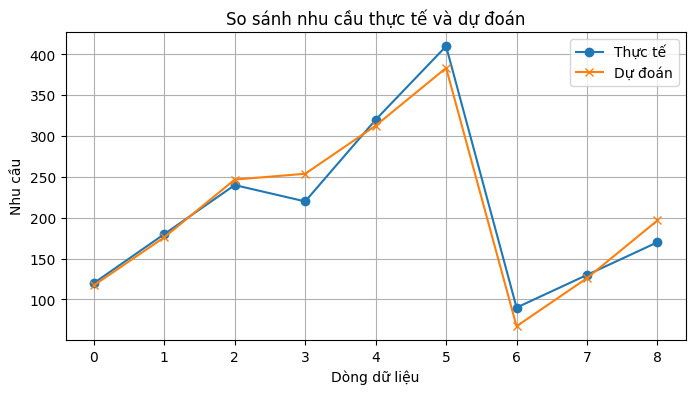

In [50]:
!pip install pandas scikit-learn matplotlib -q
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# ======================
# 1. Tạo dữ liệu mẫu
# ======================
data = pd.DataFrame([
    {"area": "A", "hour": 7,  "population": 10000, "income": 12, "demand": 120},
    {"area": "A", "hour": 12, "population": 10000, "income": 12, "demand": 180},
    {"area": "A", "hour": 18, "population": 10000, "income": 12, "demand": 240},
    {"area": "B", "hour": 7,  "population": 18000, "income": 18, "demand": 220},
    {"area": "B", "hour": 12, "population": 18000, "income": 18, "demand": 320},
    {"area": "B", "hour": 18, "population": 18000, "income": 18, "demand": 410},
    {"area": "C", "hour": 7,  "population": 9000,  "income": 10, "demand": 90},
    {"area": "C", "hour": 12, "population": 9000,  "income": 10, "demand": 130},
    {"area": "C", "hour": 18, "population": 9000,  "income": 10, "demand": 170},
])

print("Dữ liệu ban đầu:")
print(data)

# ======================
# 2. Chọn đầu vào và đầu ra
# ======================
X = data[["hour", "population", "income"]]
y = data["demand"]

# ======================
# 3. Tạo mô hình
# ======================
model = LinearRegression()
model.fit(X, y)

# ======================
# 4. Dự đoán
# ======================
data["predicted_demand"] = model.predict(X)

print("\nKết quả dự đoán:")
print(data[["area", "hour", "demand", "predicted_demand"]])

# ======================
# 5. Tính sai số
# ======================
mae = mean_absolute_error(y, data["predicted_demand"])
print("\nSai số MAE =", mae)

# ======================
# 6. Vẽ biểu đồ
# ======================
plt.figure(figsize=(8, 4))
plt.plot(data.index, data["demand"], marker="o", label="Thực tế")
plt.plot(data.index, data["predicted_demand"], marker="x", label="Dự đoán")
plt.title("So sánh nhu cầu thực tế và dự đoán")
plt.xlabel("Dòng dữ liệu")
plt.ylabel("Nhu cầu")
plt.legend()
plt.grid(True)
plt.show()